# LINEAR REGRESSION CODING

PROBLEM STATEMENT

- Predict Product sales based on TV ads Spent

Step: 1- Importing necessary libraries

In [1]:
# Data Handling

import pandas as pd    # For data handling and analysis
import numpy as np     # For numerical operation

In [3]:
# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Machine learning algorithm and utilities

from sklearn.linear_model import LinearRegression    # importing linear regression algorithm
from sklearn.model_selection import train_test_split  # Splitting dataset for training and testing

In [4]:
# Evaluation Matrix

from sklearn.metrics import mean_absolute_error, r2_score     #Evaluation matrix for regression

Step: 2 - Loading the Dataset

In [5]:
data_url = '/content/drive/MyDrive/Linear_Regression/Advertising.csv'     #Dataset locataion

data = pd.read_csv(data_url, index_col=0)                                 # Reading from CSV. index_col- index starting loc

data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Top 5 records of each ads spent value in TV, Radio and Newspaper and total sales data.

Step: 3- Summarizing the Dataset

In [6]:
data.head(10)   # Printing Top 10 records

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


In [7]:
data.tail()     # Print last 5 records

,TV,Radio,Newspaper,Sales
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5
200,232.1,8.6,8.7,13.4


In [8]:
data.info()      # Information about the dataset

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


- There are 200 records which has 200 rows and 4 columns.
- There are no null values.
- All numerical columns, no categorical data
- The dataset consumes 7.8 KB of memory.  

In [9]:
data.describe()    # Print statistical summary of dataset

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


- It shows overall count, mean, Standard deviation, minimum, maximum,25%,  50%,75% distribution of data.
- Looking at the statistical summary of data, the data is evenly distributed in all four columns.  

In [10]:
data.shape  # Printing number of rows and columns

(200, 4)

Step: 4- Preprocessing the Dataset(EDA)

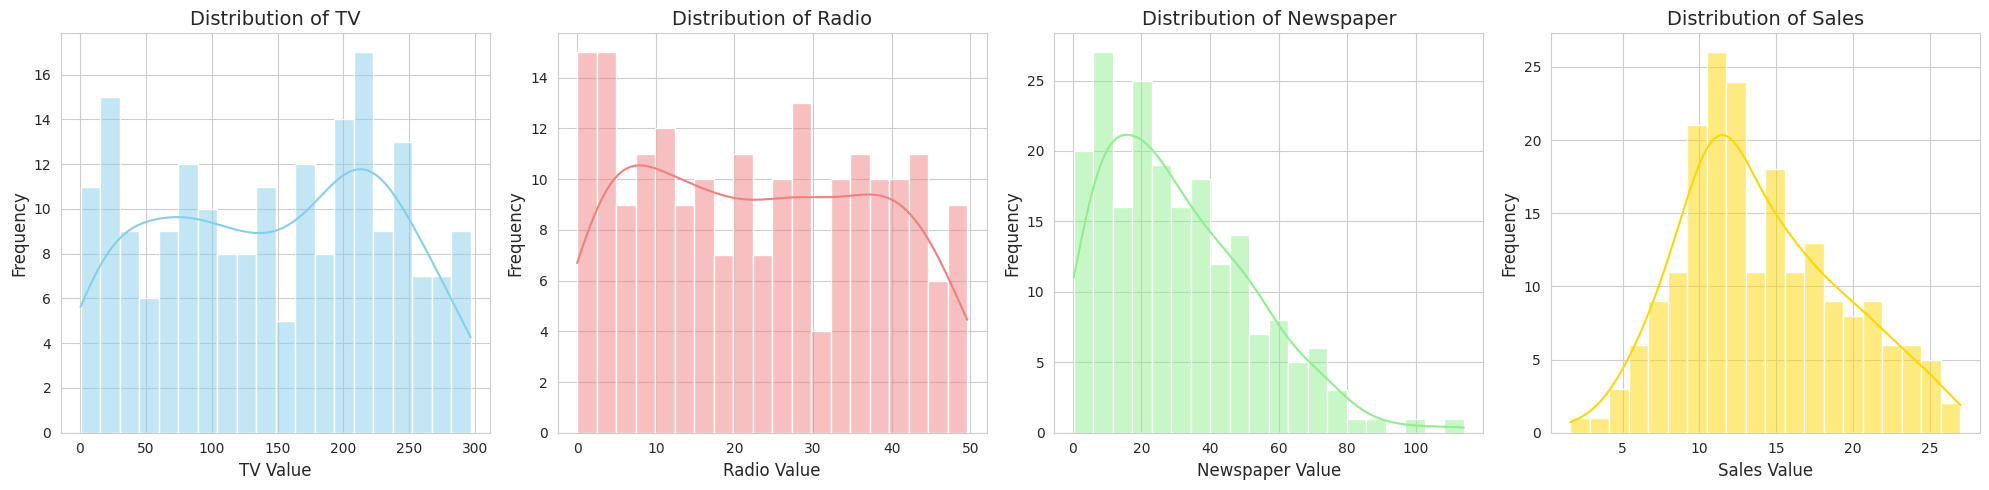

In [ ]:
# Set visualization theme

sns.set_style("whitegrid")

# Distribution of each feature and the target

plt.figure(figsize=(20, 5))

features = ['TV', 'Radio', 'Newspaper', 'Sales']

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

for i, col in enumerate(features):

    #print(i,col)

    #print('-------------')

    plt.subplot(1, 4, i + 1)

    sns.histplot(data[col], kde=True, bins=20, color=colors[i])

    plt.title(f'Distribution of {col}', fontsize=14)

    plt.xlabel(f'{col} Value', fontsize=12)

    plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()

plt.show()

The histogram distribution of TV, Radio and newspaper and sales summarize the following.

1. TV - Fairly distributed from 0 to 300 budget spending. The peak spending around 200- 230. No skew is visible.

2. Radio - Evenly distributed from 0 to 50. There is no dominant spending.

3. Newspaper - It is right skewed and most advertising budgets are b/w 0 to 40. Only few observations are in high spending(80 to 100).

4. Sales- It is normally distributed(Bell shaped curve). Most sale values fall b/w 10 to 16. Peak between to 11 to 13. Higher sales occur less frequently.

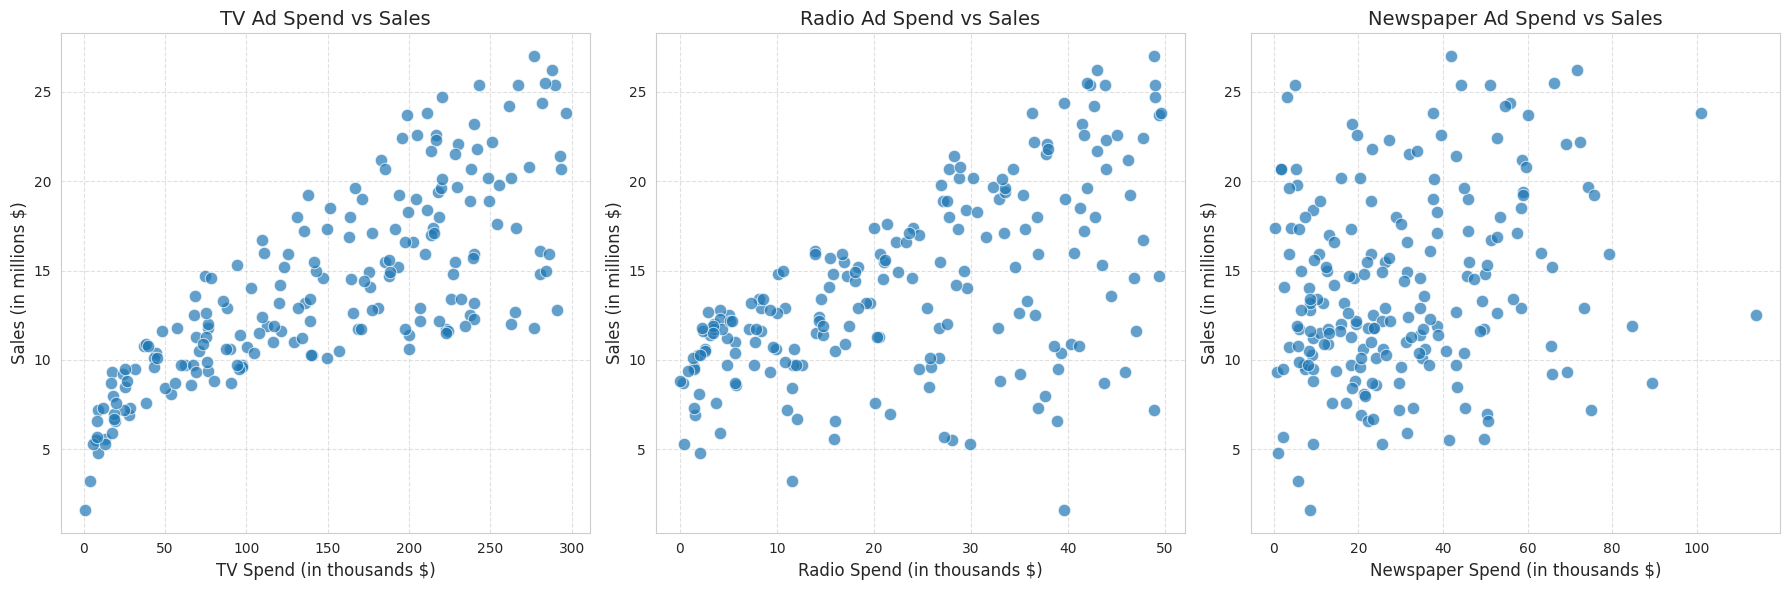

In [ ]:
# Scatter plots for Sales vs Ad Spend

plt.figure(figsize=(18, 6))

for i, col in enumerate(['TV', 'Radio', 'Newspaper']):

    plt.subplot(1, 3, i + 1)

    sns.scatterplot(x=col, y='Sales', data=data, s=80, alpha=0.7)

    plt.title(f'{col} Ad Spend vs Sales', fontsize=14)

    plt.xlabel(f'{col} Spend (in thousands $)', fontsize=12)

    plt.ylabel('Sales (in millions $)', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

Scatter plot shows the relationship between TV spent Vs Sales, Radio Vs Sales and Newspaper Vs sales.

1. TV - Strong positive linear relationship- TV advertising spend increases, sales generally increase. This is the strongest relationship among the three channels.

2. Radion- Moderate positive relationship- Higher radio spending is associated with higher sales, the data points are more dispersed than for TV.

3. Newspaper- No linear relationship- Newspaper spending shows less consistent pattern with sales, It shows minimum influence on sales.

Overall spending in TV advertising is giving better sales, followed by Radio. Newspaper advertising has less impact on sales.

Step: 5- Segregating the dataset into input and output

In [11]:
data['TV'].shape   # Dimension of TV data

(200,)

In [12]:
X = data[['TV']]   # converting to two dimensional since SK learn accepts 2D array.
Y = data['Sales']  # Target column

In [13]:
X.shape    # Now share converted to two dimensions

(200, 1)

In [14]:
X

,TV
1,230.1
2,44.5
3,17.2
4,151.5
5,180.8
...,...
196,38.2
197,94.2
198,177.0
199,283.6


In [15]:
Y

,Sales
1,22.1
2,10.4
3,9.3
4,18.5
5,12.9
...,...
196,7.6
197,9.7
198,12.8
199,25.5


Step: 6 - Splitting the dataset into training and testing data

In [16]:
X_train, X_test, Y_train,Y_test = train_test_split(X,Y, test_size = 0.2, random_state=42)   # Training- 80% and testing- 20%

In [17]:
X.shape ,Y.shape    # Printing the X and Y shape

((200, 1), (200,))

In [18]:
X_train.shape, X_test.shape, Y_train.shape,Y_test.shape   # Printing training and testing data of X and Y

((160, 1), (40, 1), (160,), (40,))

Step: 7 - Loading the Linear Regression Model

In [19]:
model = LinearRegression()      # Importing linear regression model. means linear equation(y= mx+c)

Step: 8 - Training the model

In [20]:
model.fit(X_train, Y_train)    # Using fit method to train the model

LinearRegression()

Step: 9 - Formulating the Linear Regression Equation

In [21]:
print('slope:', model.coef_)           # Printing slope (m)
print("Intercept:", model.intercept_)  # Printing intercept (c)

slope: [0.04652973]
Intercept: 7.119638430592953


In [22]:
# Y = 0.04652973X + 7.119638430592953

Step: 10 - Predicting the result using trained model

In [23]:
Y_pred = model.predict(X_test)         # Predict using the test data

In [24]:
Y_pred    # printing the predicted values

array([14.71794394, 16.2115484 , 20.74819743,  7.66403631, 17.37013877,
       10.61402143, 17.2072847 ,  9.44612512, 17.46785121, 15.2669948 ,
        8.58532504,  9.73460946, 18.03086098,  7.37089899, 13.61053628,
       15.03899911,  7.45930549, 16.31391381, 10.62332738, 18.16579721,
       17.79821232, 10.27435438,  8.88776831, 18.79394862, 10.33019006,
        9.60897918, 17.05373658, 13.60123034, 11.17703121,  7.51048819,
       16.41627922, 10.339496  , 16.37440246,  7.90599093, 20.18053468,
       18.203021  ,  9.36702457, 19.85482655, 12.57292322,  8.39920611])

In [25]:
Y_test

,Sales
96,16.9
16,22.4
31,21.4
159,7.3
129,24.7
116,12.6
70,22.3
171,8.4
175,11.5
46,14.9


Step: 11 - Calculating the loss and accuracy of the trained model

In [26]:
#accuracy

r2_score(Y_test,Y_pred)    # printing the accuracy from actual vs predicted

0.6766954295627076

- It gives the 67% accuracy. The lesser accuracy shows, the data is very less and don't have enough data the model to learn or linear regression is not the suitable alogorithm for this type of dataset.

In [ ]:
mean_absolute_error(Y_test, Y_pred)

2.444420003751042

- The mean absolute error indicates the actual vs predicted has 2 error points which is high.

Step: 12 - Visualizing the Regression Line

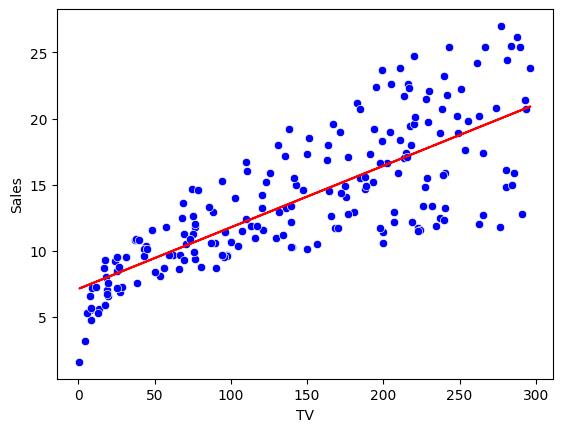

In [27]:
sns.scatterplot(x = X['TV'], y = Y, color = 'blue')   # Plot scatterplot b/w TV ads and sales
plt.plot(X,model.predict(X), color= 'red')            # Draw regression line(Best fit line) b/w entire dataset TV ads Vs predicted sales data

*For better visulization*

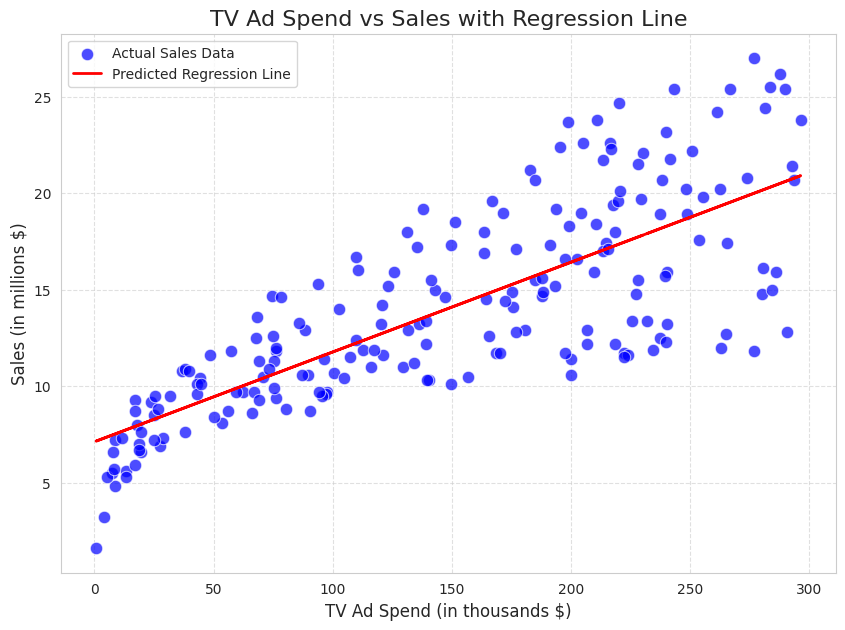

In [ ]:
# Visualizing Regression Line

plt.figure(figsize=(10, 7))

sns.scatterplot(x=X['TV'], y=Y, color='blue', s=80, alpha=0.7, label='Actual Sales Data')

plt.plot(X, model.predict(X), color='red', linewidth=2, label='Predicted Regression Line')

plt.title('TV Ad Spend vs Sales with Regression Line', fontsize=16)

plt.xlabel('TV Ad Spend (in thousands $)', fontsize=12)

plt.ylabel('Sales (in millions $)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

plt.show()

***Findings***

- The regression plot demonstrates a strong positive linear relationship between TV advertising spend and sales.

- The upward-sloping regression line shows that increasing TV advertising expenditure is associated with higher predicted sales.

- Most data points cluster close to the regression line, indicating that the linear regression model fits the data well.

- While some variability remains due to other influencing factors, the chart suggests that TV advertising is the strongest and most reliable predictor of sales, making it an effective basis for forecasting and marketing decision-making.